# Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

# Settings the warnings to be ignored
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load training data for Ahmedabad (city_hour.csv)
data = pd.read_csv("city_hour.csv")  # Update with the actual file path

# Assuming the dataset contains columns: 'DateTime', 'PM2.5', 'NO', 'NO2', 'CO', 'OtherFeatures'

data.shape

(707875, 16)

In [3]:
data.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [4]:
data.City.value_counts()

City
Ahmedabad             48192
Bengaluru             48192
Chennai               48192
Mumbai                48192
Lucknow               48192
Delhi                 48192
Hyderabad             48107
Patna                 44554
Gurugram              40258
Visakhapatnam         35053
Amritsar              29269
Jorapokhar            28025
Jaipur                26705
Thiruvananthapuram    26651
Amaravati             22784
Brajrajnagar          22468
Talcher               22161
Kolkata               19503
Guwahati              12002
Coimbatore             9229
Shillong               7402
Chandigarh             7263
Bhopal                 6903
Kochi                  3854
Ernakulam              3852
Aizawl                 2680
Name: count, dtype: int64

In [7]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 52.1 MB/s eta 0:00:00:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [8]:
from statsmodels.tsa.stattools import acf
import numpy as np

# Function to calculate seasonality strength
def calculate_seasonality_strength(city_data, period):
    city_data = city_data.dropna() # Dropping NaN values for accurate ACF calculation
    if len(city_data) < period:
        # If the data is less than the period, cannot calculate seasonality
        return np.nan
    
    autocorr = acf(city_data, fft=True, nlags=period)
    seasonal_strength = autocorr[period]
    return seasonal_strength

# Prepare a dictionary to hold seasonality strengths
seasonality_strengths = {}

# We'll assume a daily seasonality for an hourly dataset, so period=24
for city in data['City'].unique():
    city_data = data[data['City'] == city]['PM2.5'] # Example with PM2.5 pollutant
    seasonality_strengths[city] = calculate_seasonality_strength(city_data, period=24)

# Sort the cities by their seasonality strength
sorted_cities = sorted(seasonality_strengths.items(), key=lambda item: item[1], reverse=True)

# Get the top 3 cities with the strongest seasonality
top3_cities = sorted_cities[:3] if sorted_cities else []
top3_cities


[('Kolkata', np.float64(0.870663422925248)),
 ('Amaravati', np.float64(0.8388753178051684)),
 ('Delhi', np.float64(0.7667782829356993))]

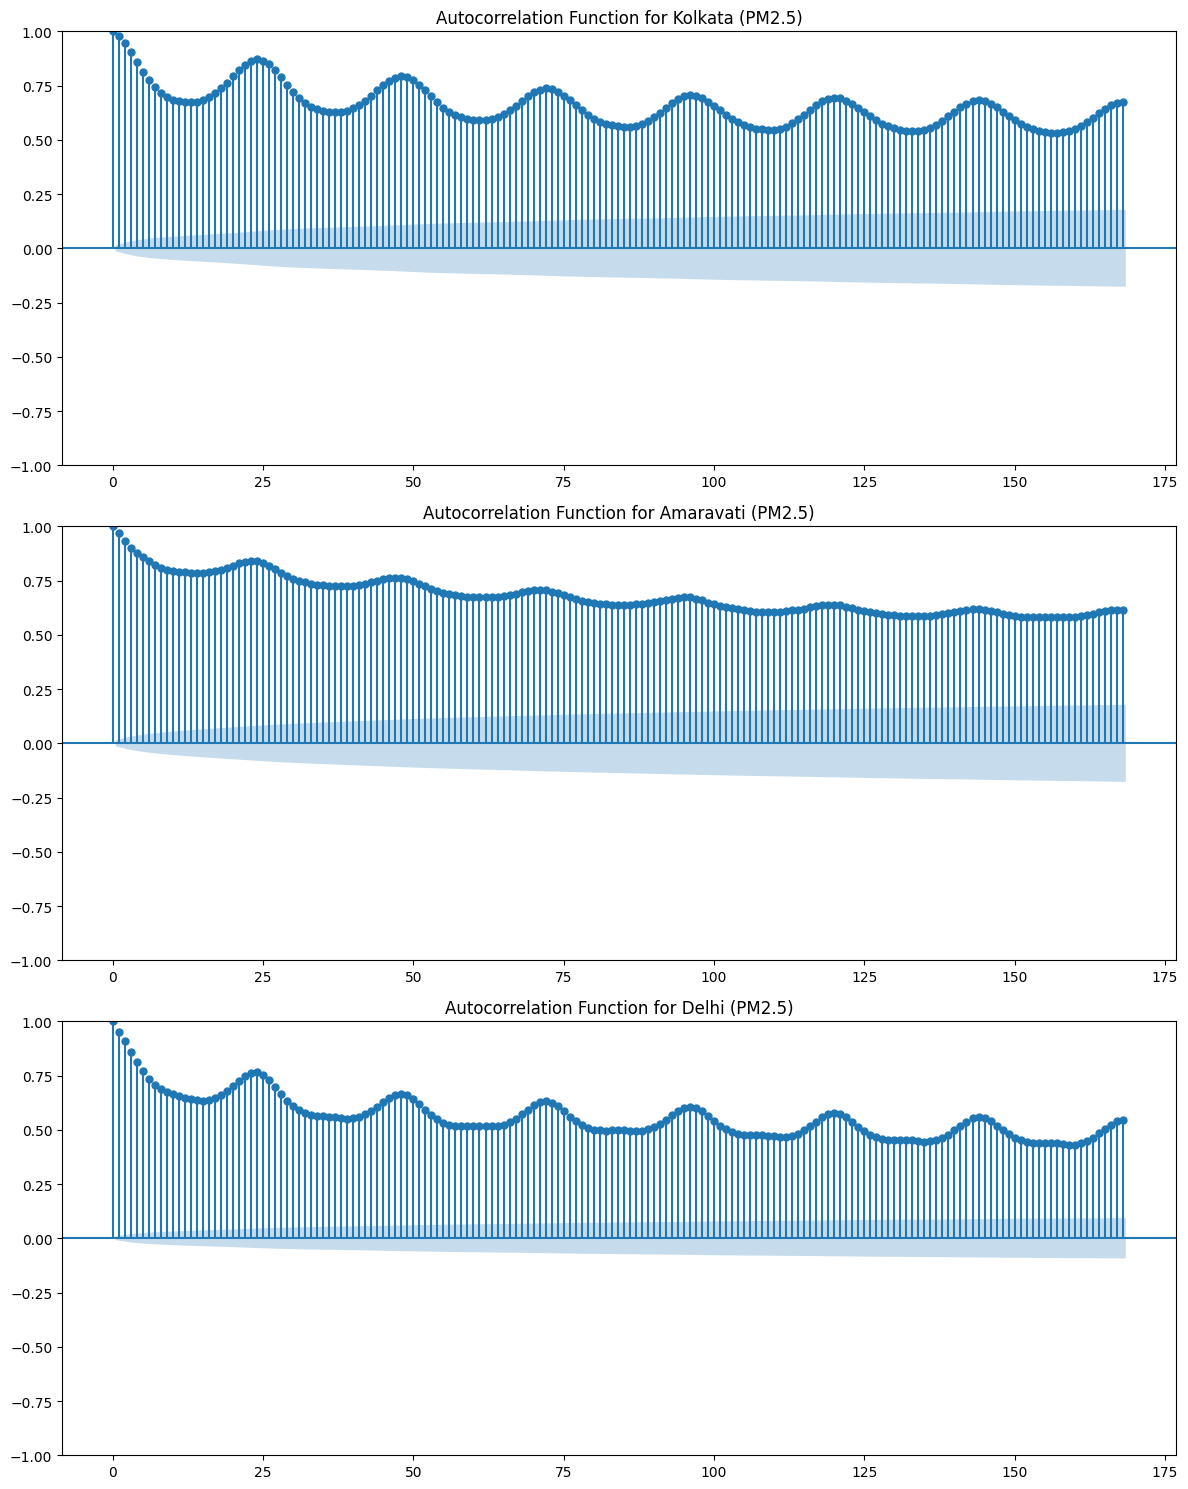

In [9]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Since we're looking for the top three, we can just take their names from the result
top_cities = [city for city, _ in top3_cities]

# Plot the ACF for the top three cities
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for i, city in enumerate(top_cities):
    # Selecting the PM2.5 data for the current city
    city_data = data[data['City'] == city]['PM2.5'].dropna()
    # Plotting the ACF
    plot_acf(city_data, lags=168, ax=axes[i])  # Display up to 168 hours (7 days) to check weekly seasonality
    axes[i].set_title(f'Autocorrelation Function for {city} (PM2.5)')

plt.tight_layout()
plt.show()


<Figure size 1200x500 with 0 Axes>

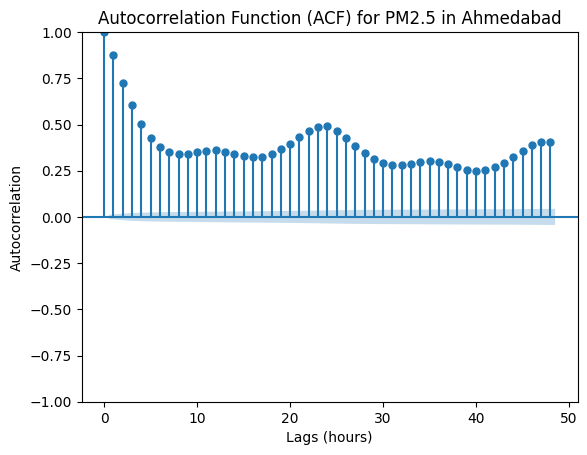

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Filter out the data for Ahmedabad
ahmedabad_pm25_data = data[data['City'] == 'Ahmedabad']['PM2.5'].dropna()

# Plot ACF for Ahmedabad's PM2.5 data
plt.figure(figsize=(12, 5))
plot_acf(ahmedabad_pm25_data, lags=48, alpha=0.05) # Plotting 48 lags to cover two days
plt.title('Autocorrelation Function (ACF) for PM2.5 in Ahmedabad')
plt.xlabel('Lags (hours)')
plt.ylabel('Autocorrelation')
plt.show()

In [11]:
data.drop(data[data['PM2.5'].isna()==True].index, axis = 0).City.value_counts()

City
Delhi                 47817
Lucknow               45032
Chennai               44876
Hyderabad             44507
Bengaluru             43561
Gurugram              34114
Patna                 33051
Ahmedabad             31129
Visakhapatnam         26157
Jaipur                26070
Amritsar              24099
Thiruvananthapuram    22916
Amaravati             19233
Mumbai                18184
Kolkata               18061
Brajrajnagar          15395
Talcher               14398
Guwahati              11558
Jorapokhar             8074
Coimbatore             7508
Chandigarh             6599
Bhopal                 6568
Shillong               4657
Kochi                  3666
Ernakulam              3431
Aizawl                 2126
Name: count, dtype: int64

In [12]:
# Filter data for Ahmedabad
ahmedabad_data = data[data['City'] == 'Ahmedabad']

# Filter data for Bengaluru/Bangalore
bengaluru_data = data[data['City'] == 'Kolkata']

In [13]:
ahmedabad_data.to_csv('ahmedabad_data.csv', index=False)

In [14]:
bengaluru_data.to_csv('bengaluru_data.csv', index=False)

In [15]:
print('Shape of Ahmedabad Dataset: ', ahmedabad_data.shape)
print('Shape of Bengaluru Dataset: ', bengaluru_data.shape)

Shape of Ahmedabad Dataset:  (48192, 16)
Shape of Bengaluru Dataset:  (19503, 16)


In [16]:
# Drop 'City' column from both datasets
ahmedabad_data.drop(columns=['City'], inplace=True)
bengaluru_data.drop(columns=['City'], inplace=True)

In [17]:
print('Shape of Ahmedabad Dataset: ', ahmedabad_data.shape)
print('Shape of Bengaluru Dataset: ', bengaluru_data.shape)

Shape of Ahmedabad Dataset:  (48192, 15)
Shape of Bengaluru Dataset:  (19503, 15)


In [18]:
ahmedabad_data['PM2.5'] = ahmedabad_data['PM2.5'].interpolate(method='linear')
ahmedabad_data['AQI'] = ahmedabad_data['AQI'].interpolate(method='linear')
ahmedabad_data['O3'] = ahmedabad_data['O3'].interpolate(method='linear')

features_to_interpolate = ['NO', 'NOx', 'NH3', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
bengaluru_data[features_to_interpolate] = bengaluru_data[features_to_interpolate].interpolate(method='linear')

# EDA

Summary Statistics of each Dataset

In [19]:
def summary(data, city):
  print('Summary of {} Dataset'.format(city))

  # Dropping specified columns
  data = data.drop(columns=['Datetime', 'AQI_Bucket'])

  # Calculating percentage of null values
  null_percent = data.isna().sum() / len(data) * 100

  # Creating a summary DataFrame
  summary = pd.DataFrame({'Null_Percent': null_percent})

  # Getting summary statistics using df.describe()
  describe_df = data.describe().T

  # Concatenating the two DataFrames
  concatenated_df = pd.concat([summary, describe_df], axis=1)

  #Generating Quantile Values
  quantiles_df = data.quantile(np.linspace(0, 1, 11))

  return concatenated_df.T, quantiles_df

In [20]:
df_summary, df_quantile = summary(ahmedabad_data, 'Ahmedabad')

Summary of Ahmedabad Dataset


In [21]:
df_summary

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
Null_Percent,1.379897,81.472029,34.507802,33.522161,32.885126,100.0,34.507802,39.917414,0.006225,27.842795,27.849021,27.863546,1.411023
count,47527.000000,8929.000000,31562.000000,32037.000000,32344.000000,0.0,31562.000000,28955.000000,48189.000000,34774.000000,34771.000000,34764.000000,47512.000000
mean,69.940868,111.493008,22.236505,59.470600,47.308052,NaN,21.999914,52.796652,43.405852,5.294880,27.464264,4.198443,394.711862
std,53.271283,55.491068,43.304767,59.855984,52.004037,NaN,43.385557,46.441455,36.425068,11.582222,36.564624,11.910355,392.610795
min,0.340000,5.650000,0.010000,0.010000,0.000000,NaN,0.010000,0.010000,0.020000,0.000000,0.000000,0.000000,34.000000
25%,41.250000,77.560000,5.340000,18.050000,17.260000,NaN,5.220000,17.220000,14.278125,0.740000,3.120000,0.350000,197.902314
50%,57.634081,101.710000,8.810000,40.040000,30.235000,NaN,8.740000,37.900000,33.870281,2.850000,22.960000,1.410000,307.728675
75%,82.946581,131.610000,20.070000,77.370000,55.692500,NaN,20.010000,76.305000,65.150000,4.687500,32.500000,4.500000,395.000000
max,999.990000,999.990000,498.570000,494.150000,498.610000,NaN,498.570000,199.960000,199.830000,381.580000,488.530000,461.390000,3133.000000


In [22]:
ahmedabad_data.drop(ahmedabad_data[ahmedabad_data['PM2.5'].isna()==True].index, axis = 0, inplace=True)

In [23]:
ahmedabad_data.shape

(47527, 15)

In [24]:
df_summary, df_quantile = summary(ahmedabad_data, 'Ahmedabad')

Summary of Ahmedabad Dataset


In [25]:
df_summary

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
Null_Percent,0.000000,81.212784,34.656090,33.902834,33.338944,100.0,34.656090,40.379153,0.000000,28.226061,28.232373,28.247102,0.031561
count,47527.000000,8929.000000,31056.000000,31414.000000,31682.000000,0.0,31056.000000,28336.000000,47527.000000,34112.000000,34109.000000,34102.000000,47512.000000
mean,69.940868,111.493008,22.262759,60.132595,47.481222,NaN,22.022314,52.991755,43.438582,5.366049,27.942254,4.226850,394.711862
std,53.271283,55.491068,43.161187,60.222884,51.843540,NaN,43.243700,46.689953,36.465730,11.658768,36.718116,11.989391,392.610795
min,0.340000,5.650000,0.010000,0.010000,0.000000,NaN,0.010000,0.010000,0.020000,0.000000,0.000000,0.000000,34.000000
25%,41.250000,77.560000,5.420000,18.260000,17.430000,NaN,5.300000,17.090000,14.254138,0.740000,3.780000,0.390000,197.902314
50%,57.634081,101.710000,8.885000,40.740000,30.590000,NaN,8.810000,38.025000,33.912819,2.880000,23.370000,1.480000,307.728675
75%,82.946581,131.610000,20.140000,78.597500,55.940000,NaN,20.092500,76.925000,65.244837,4.750000,32.520000,4.670000,395.000000
max,999.990000,999.990000,498.570000,494.150000,498.610000,NaN,498.570000,199.960000,199.830000,381.580000,488.530000,461.390000,3133.000000


In [26]:
bengaluru_data.drop(bengaluru_data[bengaluru_data['PM2.5'].isna()==True].index, axis = 0, inplace=True)

In [27]:
bengaluru_data.shape

(18061, 15)

In [28]:
df_summary_b, df_quantile_b = summary(bengaluru_data, 'Bengaluru')

Summary of Bengaluru Dataset


In [29]:
df_summary_b

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
Null_Percent,0.000000,0.011074,0.155030,0.315597,0.155030,0.027684,0.027684,0.005537,0.155030,0.155030,0.155030,48.219921,0.083052
count,18061.000000,18059.000000,18033.000000,18004.000000,18033.000000,18056.000000,18056.000000,18060.000000,18033.000000,18033.000000,18033.000000,9352.000000,18046.000000
mean,64.748260,116.284890,28.302497,40.851744,65.957851,19.029510,0.849575,8.663362,30.557419,11.525633,16.448079,2.562476,140.796415
std,65.500429,102.908192,62.505734,36.203701,77.983334,15.226224,0.676159,9.164205,27.022416,13.020408,17.073924,2.675697,105.288247
min,0.020000,1.030000,0.020000,0.160000,6.280000,0.010000,0.000000,0.070000,0.020000,0.000000,0.000000,0.000000,23.000000
25%,20.740000,42.295000,3.650000,15.700000,20.100000,9.190000,0.410000,2.730000,10.810000,2.030000,6.740000,0.880000,60.000000
50%,42.840000,79.030000,5.640000,29.110000,36.440000,14.590000,0.600000,5.930000,21.950000,5.850000,10.270000,1.890000,94.000000
75%,86.400000,162.305000,14.360000,53.252500,72.070000,25.770000,1.090000,11.280000,40.540000,18.220000,19.100000,3.220000,208.000000
max,871.240000,999.990000,498.970000,324.410000,494.730000,439.050000,6.270000,131.190000,170.420000,165.650000,250.330000,39.500000,500.000000


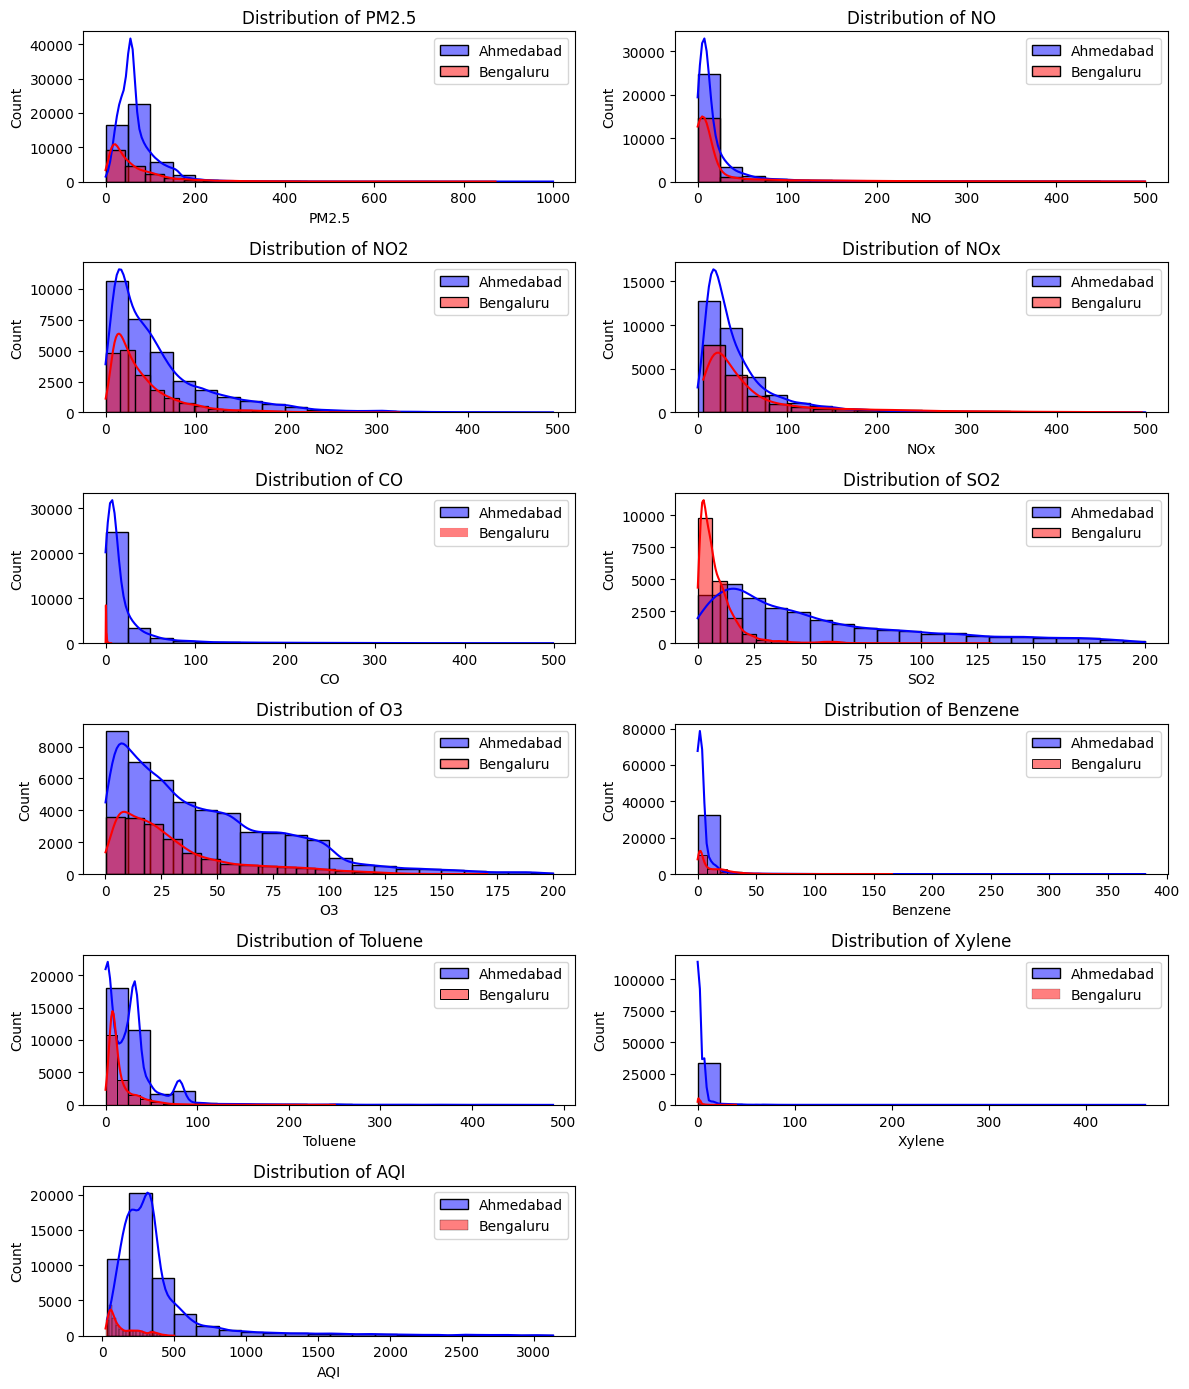

In [30]:
plt.figure(figsize=(12, 14))
for i, column in enumerate(['PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene',
       'Toluene', 'Xylene', 'AQI']):
    plt.subplot(6, 2, i+1)
    sns.histplot(ahmedabad_data[column], bins=20, kde=True, color='blue', alpha=0.5, label='Ahmedabad')
    sns.histplot(bengaluru_data[column], bins=20, kde=True, color='red', alpha=0.5, label='Bengaluru')
    plt.title(f'Distribution of {column}')
    plt.legend()
plt.tight_layout()
plt.show()

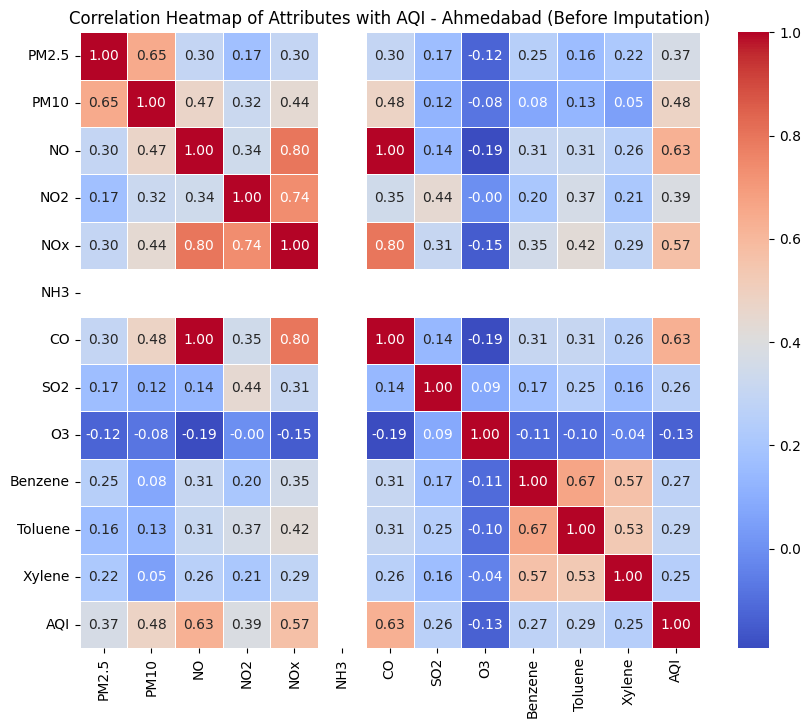

In [31]:
#Calculate correlation matrix
correlation_matrix = ahmedabad_data.drop(columns = ['Datetime', 'AQI_Bucket']).corr()

#Extract correlation of attributes with AQI
correlation_with_aqi = correlation_matrix['AQI'].drop('AQI')

#Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Attributes with AQI - Ahmedabad (Before Imputation)')
plt.show()

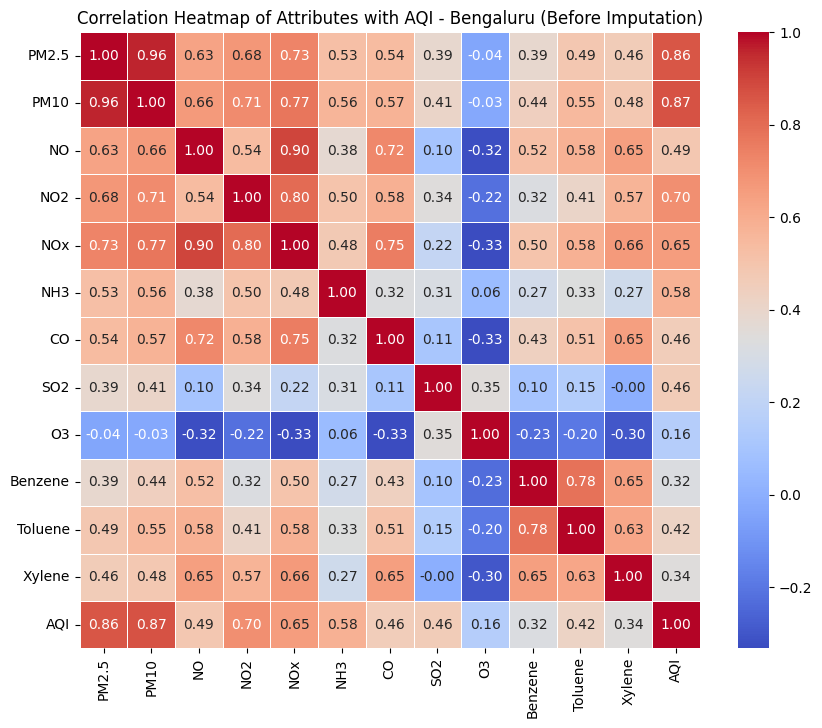

In [32]:
#Calculate correlation matrix
correlation_matrix = bengaluru_data.drop(columns = ['Datetime', 'AQI_Bucket']).corr()

#Extract correlation of attributes with AQI
correlation_with_aqi = correlation_matrix['PM2.5'].drop('PM2.5')

#Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Attributes with AQI - Bengaluru (Before Imputation)')
plt.show()

# Impute the Outliers - Based on Ahmedabad Dataset

In [33]:
df_quantile

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0.0,0.340000,5.650,0.010,0.010,0.000,NaN,0.010,0.010,0.020000,0.00,0.000,0.00,34.000000
0.1,26.738667,60.888,2.710,10.420,11.600,NaN,1.560,7.265,5.000000,0.00,0.000,0.00,137.481234
0.2,36.661451,72.480,4.780,15.050,15.520,NaN,4.400,14.180,10.689163,0.30,1.270,0.00,180.000000
0.3,45.920000,82.196,6.120,21.120,19.410,NaN,5.960,20.190,17.140273,1.15,5.810,0.52,216.000000
0.4,52.903180,91.930,7.270,30.640,24.740,NaN,7.180,27.850,24.580000,2.14,15.770,0.65,258.249614
0.5,57.634081,101.710,8.885,40.740,30.590,NaN,8.810,38.025,33.912819,2.88,23.370,1.48,307.728675
0.6,62.689493,111.970,11.170,52.108,38.180,NaN,11.090,49.180,45.112488,3.94,31.140,2.04,334.037621
0.7,73.930000,123.988,16.675,67.401,49.040,NaN,16.645,65.485,57.303560,4.16,32.320,3.21,353.000000
0.8,94.258000,140.428,25.750,93.970,65.770,NaN,25.670,90.290,74.293139,6.30,37.080,6.81,460.000000
0.9,127.937535,170.256,47.955,140.732,102.267,NaN,47.915,126.510,93.782419,11.55,65.112,7.19,693.000000


In [34]:
# Calculate skewness for each numeric column
skewness = ahmedabad_data.select_dtypes(include=[np.number]).apply(lambda x: x.skew())

# Find columns with skewness greater than a threshold (for example, 1 is commonly used)
highly_skewed_cols = skewness[skewness > 1].index.tolist()

if 'PM2.5' in highly_skewed_cols:
    highly_skewed_cols.remove('PM2.5')

# Replace highly skewed values with the 90th percentile
for col in highly_skewed_cols:
    percentile_90 = np.percentile(ahmedabad_data[col], 90)
    ahmedabad_data[col] = np.where(ahmedabad_data[col] > percentile_90, percentile_90, ahmedabad_data[col])
    bengaluru_data[col] = np.where(bengaluru_data[col] > percentile_90, percentile_90, bengaluru_data[col])


In [35]:
highly_skewed_cols

['PM10',
 'NO',
 'NO2',
 'NOx',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'Xylene',
 'AQI']

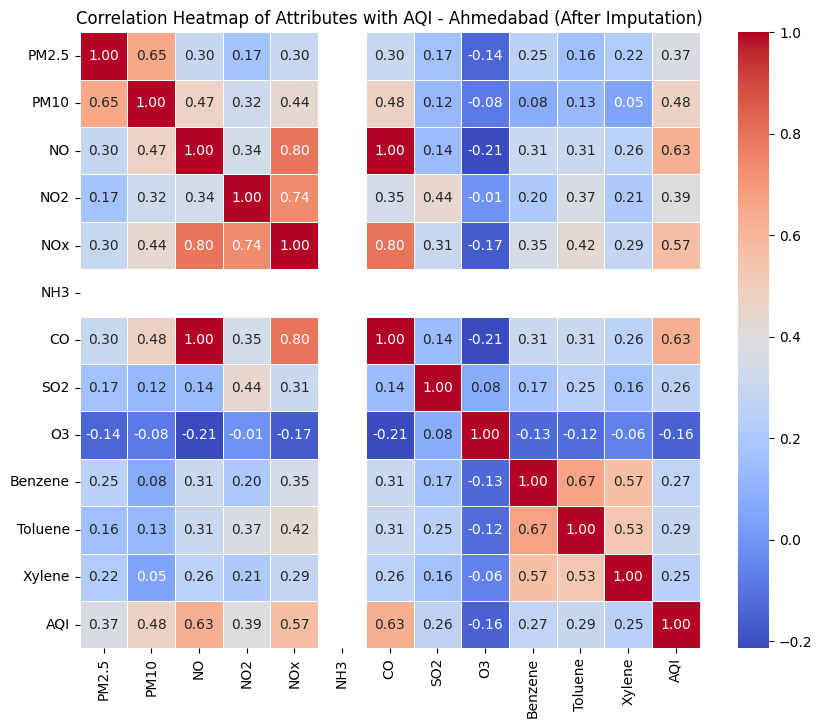

In [36]:
#Calculate correlation matrix
correlation_matrix = ahmedabad_data.drop(columns = ['Datetime', 'AQI_Bucket']).corr()

#Extract correlation of attributes with AQI
correlation_with_aqi = correlation_matrix['PM2.5'].drop('PM2.5')

#Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Attributes with AQI - Ahmedabad (After Imputation)')
plt.show()

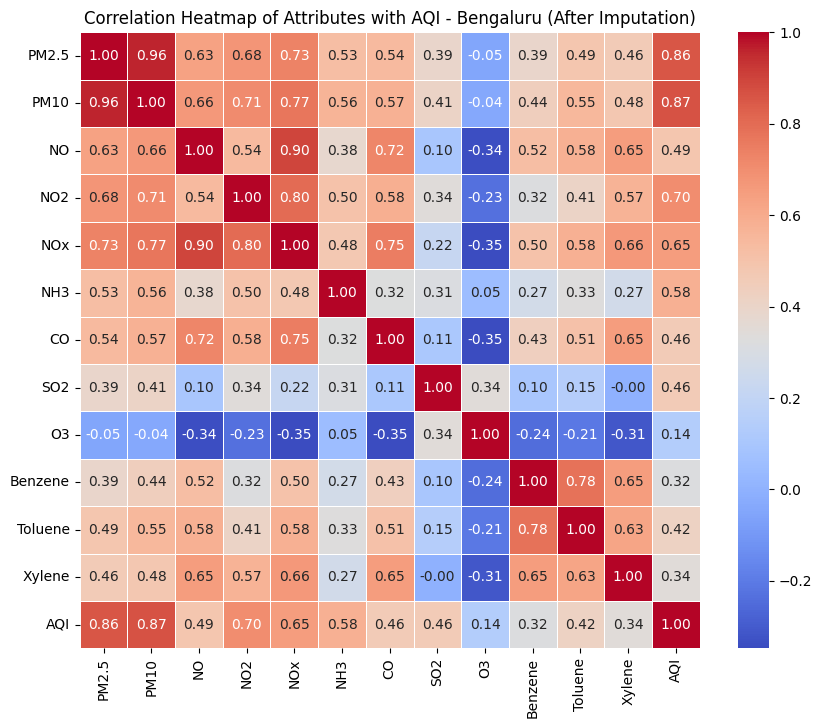

In [37]:
#Calculate correlation matrix
correlation_matrix = bengaluru_data.drop(columns = ['Datetime', 'AQI_Bucket']).corr()

#Extract correlation of attributes with AQI
correlation_with_aqi = correlation_matrix['AQI'].drop('AQI')

#Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Attributes with AQI - Bengaluru (After Imputation)')
plt.show()

# Feature Selection

In [38]:
# Convert 'Datetime' to datetime type and extract possibly useful features
ahmedabad_data['Datetime'] = pd.to_datetime(ahmedabad_data['Datetime'])
ahmedabad_data['Hour'] = ahmedabad_data['Datetime'].dt.hour
ahmedabad_data['Month'] = ahmedabad_data['Datetime'].dt.month
ahmedabad_data['Year'] = ahmedabad_data['Datetime'].dt.year

# Remove the original 'Datetime' column for correlation purposes (we use extracted features instead)
ahmedabad_data.drop('Datetime', axis=1, inplace=True)

In [39]:
# Convert 'Datetime' to datetime type and extract possibly useful features
bengaluru_data['Datetime'] = pd.to_datetime(bengaluru_data['Datetime'])
bengaluru_data['Hour'] = bengaluru_data['Datetime'].dt.hour
bengaluru_data['Month'] = bengaluru_data['Datetime'].dt.month
bengaluru_data['Year'] = bengaluru_data['Datetime'].dt.year

# Remove the original 'Datetime' column for correlation purposes (we use extracted features instead)
bengaluru_data.drop('Datetime', axis=1, inplace=True)

In [40]:
ahmedabad_data.drop(['AQI_Bucket', 'AQI'], axis=1, inplace=True)
bengaluru_data.drop(['AQI_Bucket', 'AQI'], axis=1, inplace=True)

In [41]:
# Calculate Pearson correlation coefficients
correlation_matrix = ahmedabad_data.corr(method='pearson')

In [42]:
correlation_matrix['PM2.5'].sort_values(ascending=False)

PM2.5      1.000000
PM10       0.649964
CO         0.299664
NOx        0.298996
NO         0.296852
Benzene    0.253909
Xylene     0.216462
NO2        0.174907
SO2        0.165293
Toluene    0.157967
Month      0.017552
Hour      -0.056665
O3        -0.139209
Year      -0.184377
NH3             NaN
Name: PM2.5, dtype: float64

In [43]:
ahmedabad_data.drop(columns=['PM10', 'NH3'], inplace=True)

In [44]:
bengaluru_data.drop(columns=['PM10', 'NH3'], inplace=True)

In [45]:
ahmedabad_data.reset_index(drop=True, inplace=True)
bengaluru_data.reset_index(drop=True, inplace=True)

In [46]:
ahmedabad_data = ahmedabad_data.fillna(-999)
bengaluru_data = bengaluru_data.fillna(-999)

In [47]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Define model
model = RandomForestRegressor(n_estimators=100)

# Initialize RFE with the model and desired number of features
rfe = RFE(estimator=model, n_features_to_select=10, verbose=5, step=1)

# Fit RFE
rfe.fit(ahmedabad_data.drop(columns = ['PM2.5']),ahmedabad_data['PM2.5'] )

Fitting estimator with 12 features.
Fitting estimator with 11 features.


RFE(estimator=RandomForestRegressor(), n_features_to_select=10, verbose=5)

In [ ]:
# Print results
print("Selected Features: ", ahmedabad_data.drop(columns = ['PM2.5']).columns[rfe.support_])
print("Feature Ranking: ", rfe.ranking_)

In [ ]:
selected_features = ahmedabad_data.drop(columns = ['PM2.5']).columns[rfe.support_].to_list()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    # Initializing DataFrame to store VIF scores
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data.columns
   
    # Calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
   
    return vif_data

In [ ]:
print(calculate_vif(ahmedabad_data[selected_features]))

In [ ]:
selected_features.remove('Benzene')
selected_features.remove('Xylene')

In [ ]:
selected_features.remove('NOx')

In [ ]:
print(calculate_vif(ahmedabad_data[selected_features]))

In [ ]:
selected_features.remove('NO2')

In [ ]:
print(calculate_vif(ahmedabad_data[selected_features]))

In [ ]:
selected_features.remove('Year')

In [ ]:
print(calculate_vif(ahmedabad_data[selected_features]))

In [ ]:
import numpy as np
from scipy.stats import shapiro

for f in selected_features:

    print('Feature: ', f)

    # Performing the Shapiro-Wilk test
    stat, p = shapiro(ahmedabad_data[f])

    print('Statistics=%.3f, p=%.3f' % (stat, p))

    # Interpretation
    alpha = 0.05
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
    else:
        print('Sample does not look Gaussian (reject H0)')

In [ ]:
from scipy.stats import mannwhitneyu

for f in selected_features:

    print('Feature: ', f)

    data1 = ahmedabad_data[f]
    data2 = bengaluru_data[f]

    # Performing the Mann-Whitney U test
    u_stat, p_value = mannwhitneyu(data1, data2)

    print("U-Statistic:", u_stat)
    print("P-Value:", p_value)

    # Interpretation
    alpha = 0.05
    if p_value > alpha:
        print('Same distribution (fail to reject H0)')
    else:
        print('Different distribution (reject H0)')

# Model Building

In [ ]:
source_data = ahmedabad_data[selected_features+['PM2.5']]
target_data = bengaluru_data[selected_features+['PM2.5']]

In [ ]:
source_data.reset_index(drop=True, inplace=True)
target_data.reset_index(drop=True, inplace=True)

In [ ]:
source_data.head()

In [ ]:
target_data.head()

## Splitting into Train and Test Data

In [48]:
#Define the split ratio
train_ratio = 0.8  # 80% of data for training, 20% for testing

#Calculate the index for splitting
split_index = int(len(source_data) * train_ratio)

#Split the dataset into training and testing sets
train_data = source_data.iloc[:split_index]
test_data = source_data.iloc[split_index:]

#Display the shapes of the training and testing sets
print("Training set shape:", train_data.shape)
print("Testing set shape:", test_data.shape)

NameError: name 'source_data' is not defined

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Select only numeric columns for normalization
numeric_cols = train_data.select_dtypes(include=[np.number]).columns

# Apply Min-Max scaling to numeric columns
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])

test_data[numeric_cols] = scaler.fit_transform(test_data[numeric_cols])


In [ ]:
target_data[numeric_cols] = scaler.fit_transform(target_data[numeric_cols])

#Define the split ratio
split_ratio = 0.8  # 80% of data for training, 20% for testing

#Calculate the index for splitting
split_index = int(len(target_data) * split_ratio)

#Split the dataset into training and testing sets
target_train_data = target_data.iloc[:split_index]
target_test_data = target_data.iloc[split_index:]

In [ ]:
X_source_train_data = train_data.drop('PM2.5', axis=1)
y_source_train_data = train_data[['PM2.5']]

X_source_test_data = test_data.drop('PM2.5', axis=1)
y_source_test_data = test_data[['PM2.5']]

X_target_train_data = target_train_data.drop('PM2.5', axis=1)
y_target_train_data = target_train_data[['PM2.5']]

X_target_test_data = target_test_data.drop('PM2.5', axis=1)
y_target_test_data = target_test_data[['PM2.5']]

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF plots
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(y_source_train_data.values, lags=48, ax=ax[0])  # Looking two days back
plot_pacf(y_source_train_data.values, lags=48, ax=ax[1])
plt.show()

## LSTM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import legacy
from tensorflow.keras.callbacks import ReduceLROnPlateau,  EarlyStopping
from sklearn.metrics import mean_squared_error
from math import sqrt

def create_dataset(X, y, time_steps=1, future_hours=168):
    Xs, ys = [], []
    for i in range(len(X) - time_steps - future_hours + 1):
        Xs.append(X.iloc[i:(i + time_steps)].to_numpy())
        ys.append(y.iloc[i + time_steps:i + time_steps + future_hours])
    return np.array(Xs), np.array(ys)

# Data and features setup
time_steps = 24 * 7  # Use one week of hourly data
future_hours = 24 * 7  # Predict the next week (hourly)

features = train_data[selected_features]
target = train_data['PM2.5']

X, y = create_dataset(features, target, time_steps, future_hours)

# Sequential train-test split
split_ratio = 0.8
split_index = int(X.shape[0] * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Model building with hyperparameters
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    LSTM(32, activation='tanh', return_sequences=False),
    Dense(future_hours)
])
optimizer = legacy.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Learning rate scheduler setup
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)

# Model training
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=2, validation_data=(X_test, y_test), callbacks=[lr_scheduler, early_stopping])

# Forecasting
predicted_future = model.predict(X_test)

# Evaluation
def evaluate_forecast(y_true, y_pred):
    rmse = sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    return rmse

# Calculate and print RMSE
rmse = evaluate_forecast(y_test, predicted_future)
print(f'RMSE: {rmse}')


In [ ]:
import matplotlib.pyplot as plt

# Select a sample from the test predictions and the corresponding true values
# Assuming you want to plot just the first 7 days forecast from the first sample in the test set
days_to_plot = 7 * 24  # 7 days, assuming hourly data

# Convert hours to days for x-axis labels
time_labels = np.arange(1, days_to_plot + 1) / 24

# Get the data
true_data = y_test[0, :days_to_plot]
predicted_data = predicted_future[0, :days_to_plot]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(time_labels, true_data, label='Actual PM2.5', marker='o')
plt.plot(time_labels, predicted_data, label='Predicted PM2.5', marker='x')
plt.title('PM2.5 Forecast vs Actual for the First 7 Days')
plt.xlabel('Day')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Assuming target_data is another DataFrame similar in structure to train_data
features_target = target_train_data[selected_features]
target_target = target_train_data['PM2.5']

# Use the same create_dataset function defined earlier
X_target, y_target = create_dataset(features_target, target_target, time_steps, future_hours)

# Sequential train-test split for target data
split_index_target = int(X_target.shape[0] * split_ratio)
X_target_train, X_target_test = X_target[:split_index_target], X_target[split_index_target:]
y_target_train, y_target_test = y_target[:split_index_target], y_target[split_index_target:]


In [ ]:
# Set a lower learning rate for fine-tuning
optimizer_fine_tune = legacy.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer_fine_tune, loss='mean_squared_error')

# Continue training on the target data
model.fit(X_target_train, y_target_train, epochs=50, batch_size=16, verbose=2, validation_data=(X_target_test, y_target_test), callbacks=[lr_scheduler, early_stopping])

In [ ]:
# Forecasting
predicted_future_target = model.predict(X_target_test)

# Visualizing the forecast against actual values for 7 days (assuming hourly data, 7*24=168 hours)
import matplotlib.pyplot as plt

days_to_plot = 7 * 24
time_labels = np.arange(1, days_to_plot + 1) / 24

# Assuming we are interested in the first sequence in the test set
true_data_target = y_target_test[0, :days_to_plot]
predicted_data_target = predicted_future_target[0, :days_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(time_labels, true_data_target, label='Actual PM2.5', marker='o')
plt.plot(time_labels, predicted_data_target, label='Predicted PM2.5', marker='x')
plt.title('PM2.5 Forecast vs Actual for the First 7 Days on Target Data')
plt.xlabel('Days')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Model Architecture Adjustment
model = Sequential([
    LSTM(128, activation='tanh', input_shape=(X_target_train.shape[1], X_target_train.shape[2]), return_sequences=True),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(future_hours)
])

# Add dropout for regularization
from tensorflow.keras.layers import Dropout
model.add(Dropout(0.2))

# Re-compile the model with the new architecture
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Adjust the learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

# Retrain the model on the target data
model.fit(X_target_train, y_target_train, epochs=50, batch_size=32, verbose=2, validation_data=(X_target_test, y_target_test), callbacks=[lr_scheduler, early_stopping])

# Generate new predictions and evaluate them
predicted_future_target = model.predict(X_target_test)
rmse = evaluate_forecast(y_target_test.flatten(), predicted_future_target.flatten())
print(f'Tuned RMSE: {rmse}')

# Plot the new forecast against the actual data (code for plotting remains the same as provided earlier)


In [ ]:
# Forecasting
predicted_future_target = model.predict(X_target_test)

# Visualizing the forecast against actual values for 7 days (assuming hourly data, 7*24=168 hours)
import matplotlib.pyplot as plt

days_to_plot = 7 * 24
time_labels = np.arange(1, days_to_plot + 1) / 24

# Assuming we are interested in the first sequence in the test set
true_data_target = y_target_test[0, :days_to_plot]
predicted_data_target = predicted_future_target[0, :days_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(time_labels, true_data_target, label='Actual PM2.5', marker='o')
plt.plot(time_labels, predicted_data_target, label='Predicted PM2.5', marker='x')
plt.title('PM2.5 Forecast vs Actual for the First 7 Days on Target Data')
plt.xlabel('Days')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.layers import Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Adjust the LSTM architecture: adding bidirectional and dropout
model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_target_train.shape[1], X_target_train.shape[2])))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(50)))
model.add(Dropout(0.2))
model.add(Dense(future_hours))

# Re-compile the model with a more sophisticated learning rate scheduler
optimizer = legacy.Adam()
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Callbacks: Learning rate scheduler and early stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)

# Fit the model with the new callbacks
history = model.fit(
    X_target_train,
    y_target_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_target_test, y_target_test),
    callbacks=[lr_scheduler, early_stopping],
    verbose=2
)

# Forecast and evaluate again
predicted_future_target = model.predict(X_target_test)
rmse = evaluate_forecast(y_target_test.flatten(), predicted_future_target.flatten())
print(f'Tuned RMSE: {rmse}')


In [ ]:
# Forecasting
predicted_future_target = model.predict(X_target_test)

# Visualizing the forecast against actual values for 7 days (assuming hourly data, 7*24=168 hours)
import matplotlib.pyplot as plt

days_to_plot = 7 * 24
time_labels = np.arange(1, days_to_plot + 1) / 24

# Assuming we are interested in the first sequence in the test set
true_data_target = y_target_test[0, :days_to_plot]
predicted_data_target = predicted_future_target[0, :days_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(time_labels, true_data_target, label='Actual PM2.5', marker='o')
plt.plot(time_labels, predicted_data_target, label='Predicted PM2.5', marker='x')
plt.title('PM2.5 Forecast vs Actual for the First 7 Days on Target Data')
plt.xlabel('Days')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.layers import Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Data and features setup
time_steps = 24 * 7 * 4  # Use one week of hourly data
future_hours = 24 * 7  # Predict the next week (hourly)

features = train_data[selected_features]
target = train_data['PM2.5']

X, y = create_dataset(features, target, time_steps, future_hours)

# Sequential train-test split
split_ratio = 0.8
split_index = int(X.shape[0] * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Assuming target_data is another DataFrame similar in structure to train_data
features_target = target_train_data[selected_features]
target_target = target_train_data['PM2.5']

# Use the same create_dataset function defined earlier
X_target, y_target = create_dataset(features_target, target_target, time_steps, future_hours)

# Sequential train-test split for target data
split_index_target = int(X_target.shape[0] * split_ratio)
X_target_train, X_target_test = X_target[:split_index_target], X_target[split_index_target:]
y_target_train, y_target_test = y_target[:split_index_target], y_target[split_index_target:]

# Adjust the LSTM architecture: adding bidirectional and dropout
model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_target_train.shape[1], X_target_train.shape[2])))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(50)))
model.add(Dropout(0.2))
model.add(Dense(future_hours))

# Re-compile the model with a more sophisticated learning rate scheduler
optimizer = legacy.Adam()
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Callbacks: Learning rate scheduler and early stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)

# Fit the model with the new callbacks
history = model.fit(
    X_target_train,
    y_target_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_target_test, y_target_test),
    callbacks=[lr_scheduler, early_stopping],
    verbose=2
)

# Forecast and evaluate again
predicted_future_target = model.predict(X_target_test)
rmse = evaluate_forecast(y_target_test.flatten(), predicted_future_target.flatten())
print(f'Tuned RMSE: {rmse}')


In [ ]:
# Forecasting
predicted_future_target = model.predict(X_target_test)

# Visualizing the forecast against actual values for 7 days (assuming hourly data, 7*24=168 hours)
import matplotlib.pyplot as plt

days_to_plot = 7 * 24
time_labels = np.arange(1, days_to_plot + 1) / 24

# Assuming we are interested in the first sequence in the test set
true_data_target = y_target_test[0, :days_to_plot]
predicted_data_target = predicted_future_target[0, :days_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(time_labels, true_data_target, label='Actual PM2.5', marker='o')
plt.plot(time_labels, predicted_data_target, label='Predicted PM2.5', marker='x')
plt.title('PM2.5 Forecast vs Actual for the First 7 Days on Target Data')
plt.xlabel('Days')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF plots
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(y_source_train_data, lags=48, ax=ax[0])  # Looking two days back
plot_pacf(y_source_train_data, lags=48, ax=ax[1])
plt.show()

# Fit SARIMA Model
model = SARIMAX(y_source_train_data, order=(1,0,1), seasonal_order=(1,1,1,24))
results = model.fit()

# Diagnostic plots
results.plot_diagnostics(figsize=(15, 12))
plt.show()


### Forecast for the next seven days (168 hours)

In [ ]:
from sklearn.metrics import mean_squared_error

# Forecasting
# for the next 'n' time steps
n_forecast_steps = 168
forecast = results.forecast(steps=n_forecast_steps)

train_series = y_source_train_data[-168:]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train Data')
plt.plot(forecast.index, forecast, label='SARIMA Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('SARIMA Forecasting')
plt.legend()
plt.show()

# Evaluate the model
# Convert the test set DataFrame to a pandas Series
test_series = y_source_test_data[:168]

# Forecast using the ARIMA model
forecast_test = results.forecast(steps=168)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(test_series, forecast_test)
print("Mean Squared Error (MSE):", mse)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(test_series.index, test_series, label='Test Data')
plt.plot(forecast_test.index, forecast_test, label='SARIMA Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('SARIMA Forecasting')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF plots
fig, ax = plt.subplots(2,1, figsize=(12,10))
plot_acf(y_target_train_data, lags=168, ax=ax[0])  # Looking two days back
plot_pacf(y_target_train_data, lags=168, ax=ax[1])
plt.show()


In [ ]:
# Model initialization with parameters from Ahmedabad
model_b = SARIMAX(y_target_train_data, order=(1,0,1), seasonal_order=(1,1,1,24), enforce_stationarity=False, enforce_invertibility=False)

# Fit the model
results_b = model_b.fit()

# Forecasting
# for the next 'n' time steps
n_forecast_steps = 168
forecast_b = results_b.forecast(steps=n_forecast_steps)

target_train_series = y_target_train_data[-168:]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(target_train_series.index, target_train_series, label='Target Train Data')
plt.plot(forecast_b.index, forecast_b, label='SARIMA Bengaluru Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('SARIMA Forecasting - Bengaluru')
plt.legend()
plt.show()

# Evaluate the model
# Convert the test set DataFrame to a pandas Series
target_test_series = y_target_test_data[:168]

# Forecast using the ARIMA model
forecast_test_b = results_b.forecast(steps=168)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(target_test_series, forecast_test_b)
print("Mean Squared Error (MSE):", mse)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(target_test_series.index, target_test_series, label='Target Test Data')
plt.plot(forecast_test_b.index, forecast_test_b, label='SARIMA Bengaluru Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('SARIMA Forecasting - Bengaluru')
plt.legend()
plt.show()